# Loss Landscape: Debiased Whittle vs Vecchia (Matérn ν=0.5)

**목적**: 두 방법의 loss 곡면 curvature를 같은 데이터, 같은 파라미터 범위에서 직접 비교.
- DW가 더 flat (ridge) → line search 어려움 → max_eval 크게 필요
- Vecchia가 더 sharp (bowl) → line search 빨리 수렴

**로컬 속도 설정**: Vecchia는 `keep_ori=False` (grid centers), `mm=16`, `limit_A/B=4` 사용.

In [1]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import debiased_whittle as debiased_whittle_module
from GEMS_TCO import kernels_vecchia
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

DEVICE    = torch.device("cpu")
LAT_COL, LON_COL, VAL_COL, TIME_COL = 0, 1, 2, 3
print("Imports OK")

Imports OK


In [3]:
# ── Shared config ─────────────────────────────────────────────────────────
YEAR        = '2024'
MONTH       = 7
DAY_IDX     = 0
LAT_LON_RES = [20, 20]
GRID_N      = 25

# Vecchia — match real Amarel settings (fit_gpu_vecc_day_v05_031826.py)
# limit_A : Set A — spatial neighbors at current time t
# limit_B : Set B — spatial neighbors at t-1
# limit_C : Set C — spatial neighbors at t-daily_stride
# daily_stride=2 → Set C = neighbors at t-2  (t, t-1, t-2 conditioning)
# daily_stride=8 → Set C disabled (default CLI, but real run used 2)
MM_COND      = 100
NHEADS       = 0       # real new run: nheads=0
LIMIT_A      = 8
LIMIT_B      = 8
LIMIT_C      = 8
DAILY_STRIDE = 2       # real run setting: t, t-1, t-2 conditioning

# NOTE: CPU에서 precompute_conditioning_sets() 10-20분 예상
#       daily_stride=8 (Set C 비활성)으로 바꾸면 더 빠름

# ── Center params (log space) ─────────────────────────────────────────────
c_sigmasq    = 13.059
c_range_lat  = 0.154
c_range_lon  = 0.195
c_range_time = 1.0
c_advec_lat  = 0.0218
c_advec_lon  = -0.1689
c_nugget     = 0.247

phi2 = 1.0 / c_range_lon
phi1 = c_sigmasq * phi2
phi3 = (c_range_lon / c_range_lat) ** 2
phi4 = (c_range_lon / c_range_time) ** 2

CENTER = np.array([
    np.log(phi1), np.log(phi2), np.log(phi3),
    np.log(phi4), c_advec_lat, c_advec_lon, np.log(c_nugget)
])
print("Center params:", np.round(CENTER, 4))
print(f"Target: {YEAR}-{MONTH:02d}-{DAY_IDX+1}")
print(f"Vecchia conditioning: t, t-1, t-{DAILY_STRIDE}  |  limit_A/B/C={LIMIT_A}/{LIMIT_B}/{LIMIT_C}  |  mm={MM_COND}")

Center params: [ 4.2042  1.6348  0.4721 -3.2695  0.0218 -0.1689 -1.3984]
Target: 2024-07-1
Vecchia conditioning: t, t-1, t-2  |  limit_A/B/C=8/8/8  |  mm=100


## 1. Debiased Whittle — precompute

In [4]:
# DW: is_whittle=True, keep_ori=False (grid centers → always complete grid)
data_inst = load_data_dynamic_processed(config.mac_data_load_path)

df_map_dw, _, _, monthly_mean_dw = data_inst.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=LAT_LON_RES, years_=[YEAR], months_=[MONTH],
    lat_range=[-3, 2], lon_range=[121, 131], is_whittle=True
)

daily_agg_tensors, daily_hourly_maps = [], []
for d in range(31):
    hmap, atensor = data_inst.load_working_data(
        df_map_dw, monthly_mean_dw, [d*8, (d+1)*8],
        ord_mm=None, dtype=torch.float64, keep_ori=False   # grid centers
    )
    daily_agg_tensors.append(atensor)
    daily_hourly_maps.append(hmap)

# Find first non-empty day
valid_days = [d for d in range(31) if daily_agg_tensors[d].shape[0] > 0]
print(f"Non-empty days: {valid_days}")

if DAY_IDX not in valid_days:
    DAY_IDX = valid_days[0]
    print(f"DAY_IDX adjusted → {DAY_IDX} ({YEAR}-{MONTH:02d}-{DAY_IDX+1})")
else:
    print(f"Using DAY_IDX={DAY_IDX} → {YEAR}-{MONTH:02d}-{DAY_IDX+1}")

print(f"Day tensor shape: {daily_agg_tensors[DAY_IDX].shape}")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Non-empty days: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Using DAY_IDX=0 → 2024-07-1
Day tensor shape: torch.Size([145008, 11])


In [5]:
dwl = debiased_whittle_module.debiased_whittle_likelihood()

db = debiased_whittle_module.debiased_whittle_preprocess(
    daily_agg_tensors, daily_hourly_maps,
    day_idx=DAY_IDX, params_list=CENTER.tolist(),
    lat_range=[-3, 2], lon_range=[121.0, 131.0]
)
cur_df = db.generate_spatially_filtered_days(-3, 2, 121, 131).to(DEVICE)

unique_times = torch.unique(cur_df[:, TIME_COL])
time_slices  = [cur_df[cur_df[:, TIME_COL] == t] for t in unique_times]

print("Computing J-vector and taper autocorrelation...")
J_vec, n1, n2, p_time, taper_grid, obs_masks = dwl.generate_Jvector_tapered_mv(
    time_slices, tapering_func=dwl.cgn_hamming,
    lat_col=LAT_COL, lon_col=LON_COL, val_col=VAL_COL, device=DEVICE
)
I_sample          = dwl.calculate_sample_periodogram_vectorized(J_vec)
taper_autocorr    = dwl.calculate_taper_autocorrelation_multivariate(taper_grid, obs_masks, n1, n2, DEVICE)
del obs_masks

delta1 = 5.0  / n1
delta2 = 10.0 / n2

print(f"DW precompute done. Grid: n1={n1}, n2={n2}, p_time={p_time}")


def dw_loss(log_params: np.ndarray) -> float:
    p = torch.tensor(log_params, dtype=torch.float64, device=DEVICE)
    with torch.no_grad():
        v = dwl.whittle_likelihood_loss_tapered(
            p, I_sample, n1, n2, p_time, taper_autocorr, delta1, delta2
        )
    return v.item()

print(f"DW loss @ center: {dw_loss(CENTER):.6f}")

Computing J-vector and taper autocorrelation...
DW precompute done. Grid: n1=113, n2=158, p_time=8
DW loss @ center: -0.030131


## 2. Vecchia (Matérn ν=0.5) — precompute

> `keep_ori=False` (grid centers) + `mm=16`, `limit_A/B=4`  
> Precompute conditioning sets once, then each loss eval is cheap.

In [6]:
df_map_v, ord_mm_v, nns_map_v, monthly_mean_v = data_inst.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=LAT_LON_RES,
    mm_cond_number=MM_COND,
    years_=[YEAR], months_=[MONTH],
    lat_range=[-3, 2], lon_range=[121, 131],
    is_whittle=False
)

hour_indices = [DAY_IDX * 8, (DAY_IDX + 1) * 8]
day_hourly_map_v, _ = data_inst.load_working_data(
    df_map_v, monthly_mean_v, hour_indices,
    ord_mm=ord_mm_v, dtype=torch.float64, keep_ori=False   # grid centers for speed
)
day_hourly_map_v = {k: v.to(DEVICE) for k, v in day_hourly_map_v.items()}

n_obs = sum(v.shape[0] for v in day_hourly_map_v.values())
print(f"Vecchia data loaded. Total obs: {n_obs}, time steps: {len(day_hourly_map_v)}")

--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
Vecchia data loaded. Total obs: 145008, time steps: 8


In [7]:
model_vecc = kernels_vecchia.fit_vecchia_lbfgs(
    smooth=0.5,
    input_map=day_hourly_map_v,
    nns_map=nns_map_v,
    mm_cond_number=MM_COND,
    nheads=NHEADS,
    limit_A=LIMIT_A, limit_B=LIMIT_B, limit_C=LIMIT_C,
    daily_stride=DAILY_STRIDE
)

print("Precomputing Vecchia conditioning sets (one-time)...")
model_vecc.precompute_conditioning_sets()
print("Vecchia precompute done.")


def vecc_loss(log_params: np.ndarray) -> float:
    p = torch.tensor(log_params, dtype=torch.float64, device=DEVICE)
    with torch.no_grad():
        v = model_vecc.vecchia_batched_likelihood(p)
    return v.item()

print(f"Vecchia loss @ center: {vecc_loss(CENTER):.6f}")

Precomputing Vecchia conditioning sets (one-time)...
🚀 Pre-computing 3-group Vecchia [A=8, AB=17, ABC=26, stored=1]... [Mean Lat: -0.4854] [Set C: True] ✅ Done. (Heads: 0, Tails A/AB/ABC: 18070/15920/97438)
Vecchia precompute done.
Vecchia loss @ center: 1.384286


## 3. 2D Grid Sweep — both methods

In [8]:
def sweep_2d(loss_fn, axis_x, axis_y, half_x, half_y, n=GRID_N):
    xs = np.linspace(CENTER[axis_x] - half_x, CENTER[axis_x] + half_x, n)
    ys = np.linspace(CENTER[axis_y] - half_y, CENTER[axis_y] + half_y, n)
    Z  = np.full((n, n), np.nan)
    for i, xv in enumerate(xs):
        for j, yv in enumerate(ys):
            p = CENTER.copy()
            p[axis_x] = xv
            p[axis_y] = yv
            val = loss_fn(p)
            Z[i, j] = val if np.isfinite(val) else np.nan
    return xs, ys, Z

print("Sweep function defined.")

Sweep function defined.


In [9]:
# ── Panel A: log(phi1) vs log(phi2)  [microergodic pair] ─────────────────
# phi1 = sigmasq*phi2, phi2 = 1/range_lon
# Moving along diagonal (phi1+t, phi2+t): sigmasq constant, range_lon changes
# Moving perpendicular (phi1+t, phi2-t): sigmasq changes, range_lon constant

print("Sweeping microergodic pair (phi1 vs phi2)...")
xs_A, ys_A, Z_A_dw   = sweep_2d(dw_loss,   0, 1, half_x=1.5, half_y=1.5)
print("  DW done")
xs_A, ys_A, Z_A_vecc = sweep_2d(vecc_loss, 0, 1, half_x=1.5, half_y=1.5)
print("  Vecchia done")

Sweeping microergodic pair (phi1 vs phi2)...
  DW done
  Vecchia done


In [10]:
# ── Panel B: log(phi3) vs log(phi4)  [anisotropy pair] ───────────────────
print("Sweeping anisotropy pair (phi3 vs phi4)...")
xs_B, ys_B, Z_B_dw   = sweep_2d(dw_loss,   2, 3, half_x=1.5, half_y=1.5)
print("  DW done")
xs_B, ys_B, Z_B_vecc = sweep_2d(vecc_loss, 2, 3, half_x=1.5, half_y=1.5)
print("  Vecchia done")

Sweeping anisotropy pair (phi3 vs phi4)...
  DW done
  Vecchia done


In [11]:
# ── Panel C: advec_lat vs advec_lon ──────────────────────────────────────
print("Sweeping advection pair...")
xs_C, ys_C, Z_C_dw   = sweep_2d(dw_loss,   4, 5, half_x=0.25, half_y=0.25)
print("  DW done")
xs_C, ys_C, Z_C_vecc = sweep_2d(vecc_loss, 4, 5, half_x=0.25, half_y=0.25)
print("  Vecchia done")

Sweeping advection pair...
  DW done
  Vecchia done


## 4. Side-by-side contour plots

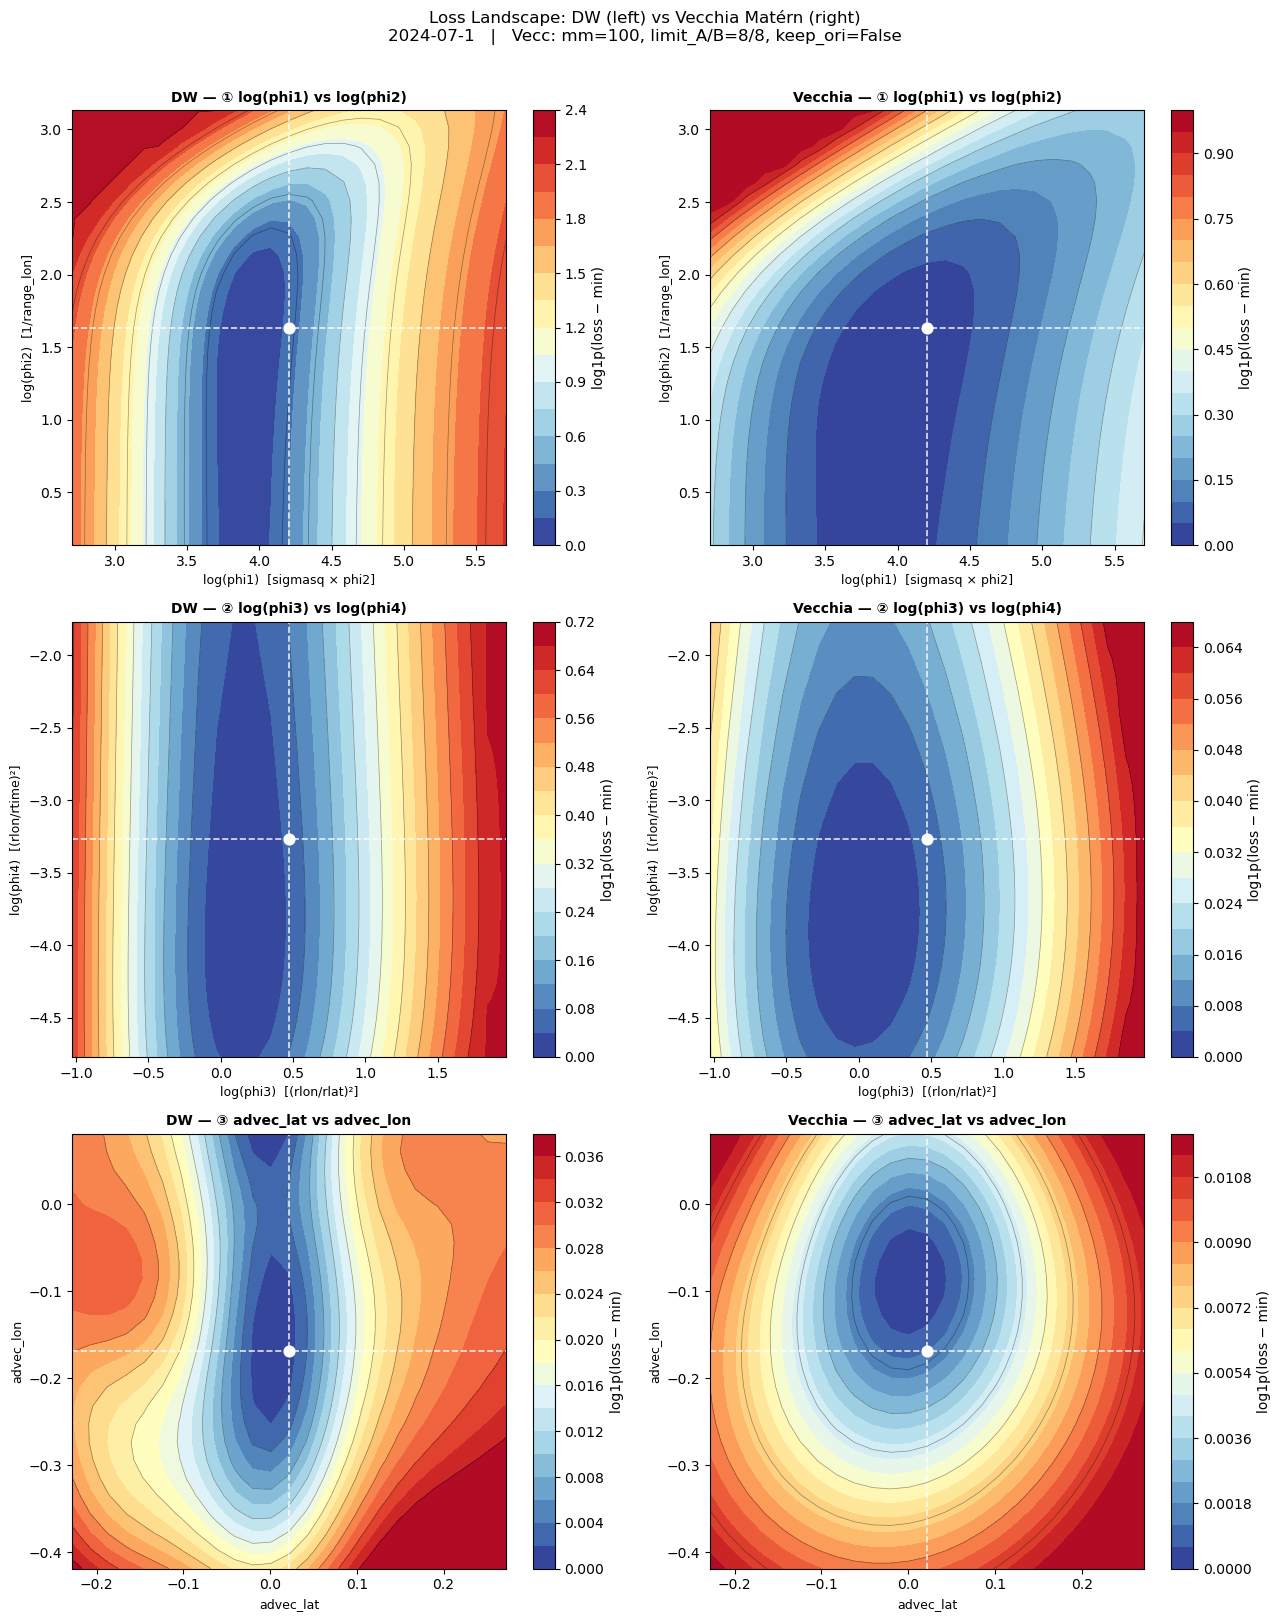

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/loss_landscape


In [12]:
def norm_loss(Z):
    """Log-normalise for visual contrast; clip top 5% to suppress outliers."""
    z = Z - np.nanmin(Z)
    p95 = np.nanpercentile(z, 95)
    z = np.clip(z, 0, p95)
    return np.log1p(z)


def panel(ax, xs, ys, Z, cx, cy, title, xlabel, ylabel):
    Zn = norm_loss(Z)
    cf = ax.contourf(xs, ys, Zn.T, levels=20, cmap='RdYlBu_r')
    ax.contour(xs, ys, Zn.T, levels=10, colors='k', linewidths=0.5, alpha=0.4)
    plt.colorbar(cf, ax=ax, label='log1p(loss − min)')
    ax.axvline(cx, color='white', lw=1.2, ls='--', alpha=0.85)
    ax.axhline(cy, color='white', lw=1.2, ls='--', alpha=0.85)
    ax.scatter([cx], [cy], color='white', s=60, zorder=5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)


fig, axes = plt.subplots(3, 2, figsize=(13, 16))
fig.suptitle(
    f'Loss Landscape: DW (left) vs Vecchia Matérn (right)\n'
    f'{YEAR}-{MONTH:02d}-{DAY_IDX+1}   |   '
    f'Vecc: mm={MM_COND}, limit_A/B={LIMIT_A}/{LIMIT_B}, keep_ori=False',
    fontsize=12, y=1.01
)

# Row 0: microergodic pair
panel(axes[0,0], xs_A, ys_A, Z_A_dw,
      CENTER[0], CENTER[1],
      'DW — ① log(phi1) vs log(phi2)',
      'log(phi1)  [sigmasq × phi2]', 'log(phi2)  [1/range_lon]')

panel(axes[0,1], xs_A, ys_A, Z_A_vecc,
      CENTER[0], CENTER[1],
      'Vecchia — ① log(phi1) vs log(phi2)',
      'log(phi1)  [sigmasq × phi2]', 'log(phi2)  [1/range_lon]')

# Row 1: anisotropy
panel(axes[1,0], xs_B, ys_B, Z_B_dw,
      CENTER[2], CENTER[3],
      'DW — ② log(phi3) vs log(phi4)',
      'log(phi3)  [(rlon/rlat)²]', 'log(phi4)  [(rlon/rtime)²]')

panel(axes[1,1], xs_B, ys_B, Z_B_vecc,
      CENTER[2], CENTER[3],
      'Vecchia — ② log(phi3) vs log(phi4)',
      'log(phi3)  [(rlon/rlat)²]', 'log(phi4)  [(rlon/rtime)²]')

# Row 2: advection
panel(axes[2,0], xs_C, ys_C, Z_C_dw,
      CENTER[4], CENTER[5],
      'DW — ③ advec_lat vs advec_lon',
      'advec_lat', 'advec_lon')

panel(axes[2,1], xs_C, ys_C, Z_C_vecc,
      CENTER[4], CENTER[5],
      'Vecchia — ③ advec_lat vs advec_lon',
      'advec_lat', 'advec_lon')

plt.tight_layout()
OUT = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/loss_landscape")
OUT.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT / f"dw_vs_vecc_landscape_{YEAR}_{MONTH:02d}_{DAY_IDX+1:02d}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT}")

## 5. 1D slice — microergodic ridge 정량 비교

**diagonal** (`phi1+t, phi2+t`): sigma² 고정, range_lon 변화 → ridge 방향  
**anti-diagonal** (`phi1+t, phi2-t`): sigma² 변화, range_lon 고정 → ridge 수직 방향

DW: diagonal이 flat, anti-diagonal이 steep  
Vecchia: 둘 다 steep이면 → curvature 더 강함

/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_65199/1537510547.py:54: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_65199/1537510547.py:54: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_65199/1537510547.py:55: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / f"dw_vs_vecc_ridge_slice_{YEAR}_{MONTH:02d}_{DAY_IDX+1:02d}.png",
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_65199/1537510547.py:55: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / f"dw_vs_vecc_ridge_slice_{YEAR}_{MONTH:02d}_{DAY_IDX+1:02d}.png",
/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph

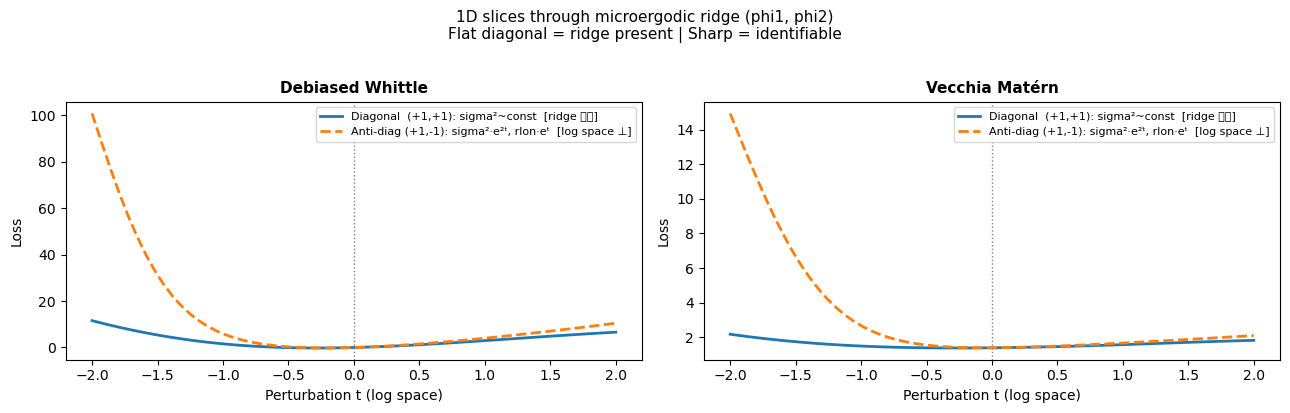

In [13]:
t_vals = np.linspace(-2.0, 2.0, 60)

# ── Direction 설명 ────────────────────────────────────────────────────────
# Diagonal   (+1,+1): log(phi1)+=t, log(phi2)+=t
#   → sigmasq = phi1/phi2 = const   ✓   (ridge 방향)
#   → range_lon = 1/phi2 = 1/(phi2·eᵗ)  변함
#
# Anti-diag  (+1,-1): log(phi1)+=t, log(phi2)-=t
#   → sigmasq = (phi1·eᵗ)/(phi2·e⁻ᵗ) = sigmasq·e^{2t}  변함
#   → range_lon = 1/(phi2·e⁻ᵗ) = range_lon·eᵗ           변함
#   → phi1·phi2 = const  (sigmasq/range_lon² = const)
#   ∴ log space에서 ridge에 수직인 방향 (둘 다 변함)
#
# Pure-phi2  ( 0,-1): log(phi1) 고정, log(phi2)-=t
#   → sigmasq = phi1/(phi2·e⁻ᵗ) = sigmasq·eᵗ   변함
#   → range_lon = 1/(phi2·e⁻ᵗ) = range_lon·eᵗ   변함
#   → phi1 고정: 순수 range_lon 이동 (sigmasq도 같이 변함)

def slice_1d(loss_fn, direction):
    vals = []
    for t in t_vals:
        p = CENTER.copy()
        p[0] += t * direction[0]
        p[1] += t * direction[1]
        vals.append(loss_fn(p))
    return np.array(vals)

dw_diag   = slice_1d(dw_loss,   (+1, +1))
dw_anti   = slice_1d(dw_loss,   (+1, -1))
vecc_diag = slice_1d(vecc_loss, (+1, +1))
vecc_anti = slice_1d(vecc_loss, (+1, -1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, ddiag, danti, title in [
    (axes[0], dw_diag,   dw_anti,   'Debiased Whittle'),
    (axes[1], vecc_diag, vecc_anti, 'Vecchia Matérn')
]:
    ax.plot(t_vals, ddiag, lw=2.0,
            label='Diagonal  (+1,+1): sigma²~const  [ridge 방향]')
    ax.plot(t_vals, danti, lw=2.0, ls='--',
            label='Anti-diag (+1,-1): sigma²·e²ᵗ, rlon·eᵗ  [log space ⊥]')
    ax.axvline(0, color='gray', lw=1, ls=':')
    ax.set_xlabel('Perturbation t (log space)', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle(
    '1D slices through microergodic ridge (phi1, phi2)\n'
    'Flat diagonal = ridge present | Sharp = identifiable',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(OUT / f"dw_vs_vecc_ridge_slice_{YEAR}_{MONTH:02d}_{DAY_IDX+1:02d}.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Numerical curvature (second derivative at center) ─────────────────────
# d²L/dt² via finite difference: (L(+h) - 2L(0) + L(-h)) / h²
# Larger → sharper → easier line search

h = 0.05
L0_dw   = dw_loss(CENTER)
L0_vecc = vecc_loss(CENTER)

def curv(loss_fn, L0, direction):
    p_plus  = CENTER.copy(); p_plus[0]  += h*direction[0]; p_plus[1]  += h*direction[1]
    p_minus = CENTER.copy(); p_minus[0] -= h*direction[0]; p_minus[1] -= h*direction[1]
    return (loss_fn(p_plus) - 2*L0 + loss_fn(p_minus)) / (h**2)

results = {
    'DW   diagonal  (+1,+1)  sigma²~const [ridge 방향]':
        curv(dw_loss,   L0_dw,   (+1, +1)),
    'DW   anti-diag (+1,-1)  sigma²·e²ᵗ, rlon·eᵗ [log ⊥]':
        curv(dw_loss,   L0_dw,   (+1, -1)),
    'Vecc diagonal  (+1,+1)  sigma²~const [ridge 방향]':
        curv(vecc_loss, L0_vecc, (+1, +1)),
    'Vecc anti-diag (+1,-1)  sigma²·e²ᵗ, rlon·eᵗ [log ⊥]':
        curv(vecc_loss, L0_vecc, (+1, -1)),
}

print("\n=== Numerical 2nd derivative (curvature) at center ===")
print(f"{'Direction':<55} {'d²L/dt²':>10}  interpretation")
print("-" * 85)
for name, val in results.items():
    interp = '← FLAT (ridge)' if abs(val) < 0.5 else '← STEEP (identifiable)'
    print(f"{name:<55} {val:>10.4f}  {interp}")


=== Numerical 2nd derivative (curvature) at center ===
Direction                                                  d²L/dt²  interpretation
-------------------------------------------------------------------------------------
DW   diagonal  (+1,+1)  sigma²~const [ridge 방향]             4.5171  ← STEEP (identifiable)
DW   anti-diag (+1,-1)  sigma²·e²ᵗ, rlon·eᵗ [log ⊥]         6.7365  ← STEEP (identifiable)
Vecc diagonal  (+1,+1)  sigma²~const [ridge 방향]             0.2690  ← FLAT (ridge)
Vecc anti-diag (+1,-1)  sigma²·e²ᵗ, rlon·eᵗ [log ⊥]         0.8847  ← STEEP (identifiable)
